# Generate a synthetic dataset

This notebook starts the process to generate a synthetic dataset taken already created structural models.

In [7]:
from core.vtk_utilities import *
from core.utilities import *
from core.widgets_utilities import *
from core.all_features2 import all_features2
from core.tk_utilities import *
import io

## Select files with the structural models 

Select the files that contain the structural models you want to have in your synthetic dataset. At least an input model is required.

We have 4 types of models and 4 buttons to adds it:

- Membrane files: list of membranes files to use in the application these have **mbs** extension
- Filament files: list of filament files to use in the application these have **hns** extension
- Macromolecule (protein) files: list of macromolecule files to use in the application these have **pns** extension
- Membrane protein files: list of membrane macromolecule files to use in the application these have **pms** extension

  
**Note** you can select many (an all) files in a folder with the usage of **'Ctrl'** key.

Remember to select the membrane proteins that you have already **aligned** otherwise the application will not work correctly.


In [4]:
selected_files_path_membrane = []
selected_files_path_helix = []
selected_files_path_proteins= []
selected_files_path_mproteins = []
MEMBRANES_LIST = []
HELIX_LIST = []
PROTEINS_LIST = []
MB_PROTEINS_LIST = []

def select_files_membrane(btn):
    global selected_files_path_membrane
    select_files(selected_files_path_membrane, ".mbs")
    add_files(MEMBRANES_LIST, selected_files_path_membrane)
    update_dropdown(MEMBRANES_LIST, dropdown_membrane)
 
    
def select_files_helix(btn):
    global selected_files_path_helix
    select_files(selected_files_path_helix, ".hns")
    add_files(HELIX_LIST, selected_files_path_helix)
    update_dropdown(HELIX_LIST, dropdown_helix)


def select_files_proteins(btn):
    global selected_files_path_proteins
    select_files(selected_files_path_proteins, ".pns")
    add_files(PROTEINS_LIST, selected_files_path_proteins)
    update_dropdown(PROTEINS_LIST, dropdown_proteins)


def select_file_mproteins(btn):
    global selected_files_path_mproteins
    select_files(selected_files_path_mproteins, ".pms")
    add_files(MB_PROTEINS_LIST, selected_files_path_mproteins)
    update_dropdown(MB_PROTEINS_LIST, dropdown_mproteins)


(select_file_button_membrane, dropdown_membrane,select_file_button_helix, dropdown_helix, select_file_button_proteins,
 dropdown_proteins, select_file_button_mproteins, dropdown_mproteins) = widgets_add_app_files()
select_file_button_membrane.on_click(select_files_membrane)
select_file_button_helix.on_click(select_files_helix)
select_file_button_proteins.on_click(select_files_proteins)
select_file_button_mproteins.on_click(select_file_mproteins)

## Sort the models

Models selected can be sorted to determine the specific order to be simulated. Labels in ground truth will correspond with the order defined here starting with label '1' ('0' is reserved for background).

In [3]:
def up_file_m(b):
    index, options = up_file_priority(MEMBRANES_LIST,  MEMBRANES_WIDGETS[2].value)
    if len(options)>0:
        MEMBRANES_WIDGETS[2].options = options
        MEMBRANES_WIDGETS[2].value = options[index]

def down_file_m(b):
    index, options = down_file_priority(MEMBRANES_LIST,  MEMBRANES_WIDGETS[2].value)
    if len(options)>0:
        MEMBRANES_WIDGETS[2].options = options
        MEMBRANES_WIDGETS[2].value = options[index]
    
def up_file_p(b):
    index, options = up_file_priority(PROTEINS_LIST,  PROTEINS_WIDGETS[2].value)
    if len(options) >0:
        PROTEINS_WIDGETS[2].options = options
        PROTEINS_WIDGETS[2].value = options[index]

def down_file_p(b):
    index, options = down_file_priority(PROTEINS_LIST,  PROTEINS_WIDGETS[2].value)
    if len(options) >0:
        PROTEINS_WIDGETS[2].options = options
        PROTEINS_WIDGETS[2].value = options[index]
    
def up_file_mb(b):
    index, options = up_file_priority(MB_PROTEINS_LIST,  MB_PROTEINS_WIDGETS[2].value)
    if len(options) > 0:
        MB_PROTEINS_WIDGETS[2].options = options
        MB_PROTEINS_WIDGETS[2].value = options[index]

def down_file_mb(b):
    index, options = down_file_priority(MB_PROTEINS_LIST,  MB_PROTEINS_WIDGETS[2].value)
    if len(options) > 0:
        MB_PROTEINS_WIDGETS[2].options = options
        MB_PROTEINS_WIDGETS[2].value = options[index]
    
def up_file_h(b):
    index, options = up_file_priority(HELIX_LIST,  HELIX_WIDGETS[2].value)
    if len(options) > 0:
        HELIX_WIDGETS[2].options = options
        HELIX_WIDGETS[2].value = options[index]

def down_file_h(b):
    index, options = down_file_priority(HELIX_LIST,  HELIX_WIDGETS[2].value)
    if len(options) > 0:
        HELIX_WIDGETS[2].options = options
        HELIX_WIDGETS[2].value = options[index]

def update_dropdown_widget(widget, values):
    widget.options = values
    widget.value = values[0] if values else None

def on_membranes_list_change(btn):
    update_dropdown_widget(MEMBRANES_WIDGETS[2], MEMBRANES_LIST)
def on_helix_list_change(btn):
    update_dropdown_widget(HELIX_WIDGETS[2], HELIX_LIST)
def on_proteins_list_change(btn):
    update_dropdown_widget(PROTEINS_WIDGETS[2], PROTEINS_LIST)
def on_mb_proteins_list_change(btn):
    update_dropdown_widget(MB_PROTEINS_WIDGETS[2], MB_PROTEINS_LIST)


select_file_button_membrane.on_click(on_membranes_list_change)
select_file_button_helix.on_click(on_helix_list_change)
select_file_button_proteins.on_click(on_proteins_list_change)
select_file_button_mproteins.on_click(on_mb_proteins_list_change)

(MEMBRANES_WIDGETS, HELIX_WIDGETS, PROTEINS_WIDGETS, MB_PROTEINS_WIDGETS)= widgets_change_order([MEMBRANES_LIST, HELIX_LIST, PROTEINS_LIST, MB_PROTEINS_LIST])

MEMBRANES_WIDGETS[0].on_click(up_file_m)
MEMBRANES_WIDGETS[1].on_click(down_file_m)
HELIX_WIDGETS[0].on_click(up_file_h)
HELIX_WIDGETS[1].on_click(down_file_h)
PROTEINS_WIDGETS[0].on_click(up_file_p)
PROTEINS_WIDGETS[1].on_click(down_file_p)
MB_PROTEINS_WIDGETS[0].on_click(up_file_mb)
MB_PROTEINS_WIDGETS[1].on_click(down_file_mb)

## Execution

Once defined the list of models to be used in the simulation, select the parameters related with the simulation and image acquisition press **Exec** to run the simulation.

In [8]:
DEF_PATH = os.path.realpath(os.getcwd() + '/../data') +  '/../data_generated/polnet_test'
def generate_voi_shape():
    return (voi_shape1.value, voi_shape2.value, voi_shape3.value)

def generate_tilts_angs():
    return range(widget_min.value, widget_max.value, widget_paso.value)

def generate_voi_off():
    return ((voi_off_widget_1.value, voi_off_widget_2.value),
            (voi_off_widget_3.value, voi_off_widget_4.value),
            (voi_off_widget_5.value, voi_off_widget_6.value))



def exec_app(btn):
    with output_widget:
        path = check_dir(widget_out_dir.selected_path, DEF_PATH)
        if MEMBRANES_LIST or HELIX_LIST or PROTEINS_LIST or MB_PROTEINS_LIST:
            all_features2(ntomos_widget.value, generate_voi_shape(),
                          path, generate_voi_off(), voi_size_widget.value,
                          mmer_tries_widget.value, pmer_tries_widget.value,
                          MEMBRANES_LIST, HELIX_LIST, PROTEINS_LIST, MB_PROTEINS_LIST,
                          surf_dec_widget.value,
                          generate_tilts_angs(), [detector_snr_widget_low.value, detector_snr_widget_high.value],
                          malign_mn_widget.value, malign_mx_widget.value, malign_sg_widget.value)
        else:
            window_exec_app_failed()


(widget_out_dir, ntomos_widget, voi_shape1, voi_shape2, voi_shape3, voi_off_widget_1, voi_off_widget_2, voi_off_widget_3, voi_off_widget_4, 
voi_off_widget_5, voi_off_widget_6,voi_size_widget, mmer_tries_widget, 
pmer_tries_widget, surf_dec_widget, malign_mn_widget, malign_mx_widget, malign_sg_widget, 
detector_snr_widget_low, detector_snr_widget_high, widget_min, widget_max, widget_paso, exec_button) = widgets_exec_app()

output_widget = widgets.Output()

exec_button.on_click(exec_app)
display(output_widget)

FileChooser(path='/home/tomo/kaggle/polnet/gui', filename='', title='Select where you want to save the output …

IntText(value=1, description='N_TOMOS (number of tomograms in the dataset):', layout=Layout(width='380px'), st…

BoundedFloatText(value=10.0, description='VOI_VOXEL_SIZE (Voxel size, voxels/A):', layout=Layout(width='350px'…

BoundedFloatText(value=20.0, description='MMER_TRIES (Maximun number of tries for monomers):', layout=Layout(w…

BoundedFloatText(value=100.0, description='PMER_TRIES (Maximun number of tries for polymers):', layout=Layout(…

...

BoundedFloatText(value=1.0, description='MALIGN_MN (Micrograph miss-alginment mean, pixels):', layout=Layout(w…

BoundedFloatText(value=1.5, description='MALIGN_MX (Micrograph miss-alginment max, pixels):', layout=Layout(wi…

BoundedFloatText(value=0.2, description='MALIGN_SG (Micrograph miss-alginment sigma, pixels):', layout=Layout(…

Button(description='Exec', style=ButtonStyle())

Output()

# all_features2関数の引数・パラメータの説明

`all_features2` 関数は、合成（シミュレーション）トモグラムを生成するために使用されます。以下は、この関数に渡す各引数・パラメータの意味について、専門知識がない方にもわかりやすく説明したものです。

---

### 1. **NTOMOS**
- **意味**: 生成するトモグラム（3D画像）の数。
- **説明**: 例えば、`NTOMOS=10`と設定すると、10個の異なる3D画像が作成されます。

### 2. **VOI_SHAPE**
- **意味**: 注目領域（Volume of Interest, VOI）の形状。
- **説明**: 解析したい特定の部分の形状を設定します。例えば、立方体や球体などです。

### 3. **OUT_DIR**
- **意味**: 出力ファイルを保存するディレクトリのパス。
- **説明**: 生成されたデータや結果が保存される場所を指定します。

### 4. **VOI_OFFS**
- **意味**: VOIのオフセット（位置）を指定する設定。
- **説明**: VOIを画像内のどの位置に配置するかを決めます。具体的には、開始点と終了点の座標を指定します。

### 5. **VOI_VSIZE**
- **意味**: VOIのピクセルサイズ。
- **説明**: VOI内の1ピクセルが実際のどれくらいのサイズを表すかを設定します（例: 1ピクセル=10アンストローム）。

### 6. **MMER_TRIES**
- **意味**: マクロモレキュールの配置試行回数。
- **説明**: シミュレーション中にマクロモレキュール（大きな分子構造）が配置される試行回数を指定します。多いほど複雑な構造になります。

### 7. **PMER_TRIES**
- **意味**: ミクロモレキュールの配置試行回数。
- **説明**: ミクロモレキュール（小さな分子構造）の配置試行回数を指定します。

### 8. **MEMBRANES_LIST**
- **意味**: 使用する膜（メンブレン）ファイルのリスト。
- **説明**: シミュレーションに使用する膜構造のデータファイルのパスを指定します。複数の膜モデルを使う場合にリストで指定します。

### 9. **HELIX_LIST**
- **意味**: 使用するフィラメント（ヘリックス）ファイルのリスト。
- **説明**: シミュレーションに含めるフィラメントのデータファイルのパスを指定します。

### 10. **PROTEINS_LIST**
- **意味**: 使用するマクロモレキュール（タンパク質）のファイルリスト。
- **説明**: シミュレーションに含めるタンパク質のデータファイルをリストで指定します。

### 11. **MB_PROTEINS_LIST**
- **意味**: 使用する膜タンパク質（膜に結合したタンパク質）のファイルリスト。
- **説明**: 膜に結合したタンパク質のデータファイルを指定します。

### 12. **SURF_DEC**
- **意味**: サーフェスディテールの調整。
- **説明**: 表面の詳細度を設定します。高い値にすると、より詳細な表面が生成されます。

### 13. **TILT_ANGS**
- **意味**: チルト角の配列。
- **説明**: 3D再構築のために画像を取得する際の角度を指定します。複数の角度を設定することで立体的な情報を取得します。

### 14. **DETECTOR_SNR**
- **意味**: 検出器の信号対雑音比（Signal-to-Noise Ratio）。
- **説明**: シミュレーションにおける信号の強さと雑音の比率を設定します。高い値はクリアな信号を示し、低い値はノイズが多いことを示します。

### 15. **MALIGN_MN**
- **意味**: マイクロズミスアラインメントの最小値。
- **説明**: シミュレーション中の微小な配置ずれの最小値を設定します。

### 16. **MALIGN_MX**
- **意味**: マイクロズミスアラインメントの最大値。
- **説明**: シミュレーション中の微小な配置ずれの最大値を設定します。

### 17. **MALIGN_SG**
- **意味**: マイクロズミスアラインメントの標準偏差。
- **説明**: 配置ずれのばらつきを設定します。値が大きいほどランダム性が高くなります。

### 18. **random_seed** (デフォルト値: 171717)
- **意味**: 乱数シード値。
- **説明**: シミュレーションの再現性を保証するために使用します。同じシード値を使うと、同じ結果が得られます。

---

## まとめ

`all_features2` 関数は、これらの引数を使って複雑な3D構造のシミュレーションを行います。各パラメータは、シミュレーションの詳細（例えば、生成するトモグラムの数や構造の種類、保存場所など）を設定するために使用されます。これらを適切に設定することで、目的に沿った合成データセットを生成することができます。

**補足説明**:

- **トモグラム（Tomogram）**: 3次元構造を持つ画像データ。医療や材料科学などで内部構造の解析に使用されます。
- **VOI（Volume of Interest）**: 解析や処理の対象となる特定の領域。
- **マクロモレキュール**: 大きな分子構造。主にタンパク質や核酸など。
- **ミクロモレキュール**: 比較的小さな分子構造。例えば、リガンドや小分子薬剤など。

これらのパラメータを理解し、適切に設定することで、効果的にシミュレーションを行い、必要なデータセットを生成することができます。

[0. 1. 2. 3. 4. 5. 6. 7.]


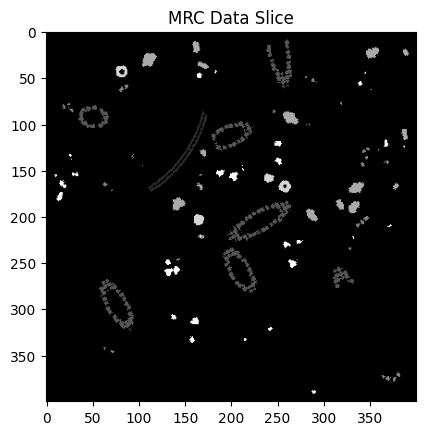

In [5]:
import mrcfile
import matplotlib.pyplot as plt

# MRCファイルを読み込みます
with mrcfile.open('/home/tomo/kaggle/polnet/output/4/tomos/tomo_lbls_0.mrc', permissive=True) as mrc:
    data = mrc.data

print(np.unique(data))

# データの断面を可視化します
plt.imshow(data[data.shape[0] // 2, :, :], cmap='gray')
plt.title('MRC Data Slice')
plt.show()

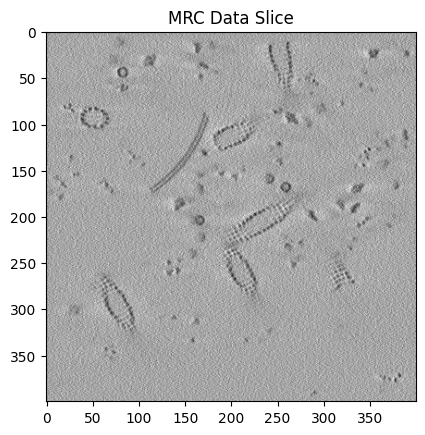

In [8]:
import mrcfile
import matplotlib.pyplot as plt
from glob import glob

# MRCファイルを読み込みます
file = glob('/home/tomo/kaggle/polnet/output/4/tomos/tomo_rec_0_snr*.mrc')[0]
with mrcfile.open(file, permissive=True) as mrc:
    data = mrc.data

# データの断面を可視化します
plt.imshow(data[data.shape[0] // 2, :, :], cmap='gray')
plt.title('MRC Data Slice')
plt.show()

提供されたPythonスクリプト all_features2.py は、合成トモグラム（3次元の構造データ）を生成するために設計されています。主に計算生物学や材料科学などの分野で利用されるトモグラムは、細胞や分子の構造を詳細に解析するために使用されます。以下に、このスクリプトの主要なコンポーネントと処理の流れを日本語で説明します。

インポートおよび依存関係
スクリプトの冒頭では、標準ライブラリ（sys、csv、time、random、numpy）と、カスタムモジュールである polnet パッケージから複数のクラスや関数がインポートされています。これらのインポートは、ポリマーのモデル化、ネットワーク生成、膜構造の設定、ランダム生成など、複雑な3D構造の作成に必要な機能を提供します。

関数: all_features2
all_features2 関数はスクリプトの中心となる部分で、以下の手順でトモグラムを生成します。

ランダムシードの設定: 再現性を確保するために、Pythonの random モジュールとNumPyのランダムシードが設定されます。これにより、ランダムな要素が含まれるトモグラム生成が毎回同じ結果を生み出します。

ディレクトリの設定: 生成されたトモグラムや関連データを保存するための出力ディレクトリ（OUT_DIR、TEM_DIR、TOMOS_DIR）が設定され、存在しない場合は作成されます。また、既存のデータが存在する場合はクリーンアップされます。

ラベルテーブルの作成: labels_table.csv ファイルが生成され、膜、ヘリックス、タンパク質、膜結合タンパク質など、異なるモデルに対して一意のラベルが割り当てられます。これは、トモグラム内で各構造を識別するために重要です。

トモグラム生成ループ: 指定された数 (NTOMOS) のトモグラムを生成するためにループが実行されます。各トモグラムについて以下の処理が行われます：

VOI（関心領域）と密度の初期化: VOI_SHAPE に基づいて関心領域が設定され、その領域内のボクセル（3Dピクセル）の密度値が初期化されます。

膜の生成: MEMBRANES_LIST にリストアップされた各膜ファイルに対して、膜の種類（球形、楕円形、トロイダル形）に応じた生成器を使用して膜構造がVOI内に配置されます。生成された膜の密度とラベル情報が更新されます。

ヘリコイド構造（アクチンおよび微小管）の生成: HELIX_LIST にリストアップされた各ヘリコイドファイルに対して、アクチンや微小管のパラメータをロードし、対応するポリマー単位とネットワークを生成します。これにより、ヘリコイド構造がVOI内に配置され、密度とラベルが更新されます。

タンパク質の生成: PROTEINS_LIST にリストアップされた各タンパク質ファイルに対して、セルフ・アボイディング・ウォーク・リニア・コンストレインツ（SAWLC）モデルを使用してポリマーが生成され、トモグラムに挿入されます。

膜結合タンパク質の生成: MB_PROTEINS_LIST にリストアップされた膜結合タンパク質に対して、既存の膜構造に関連付けられたポリマーが生成され、トモグラムに挿入されます。

統計と出力: 各トモグラムの生成後、膜、アクチン、微小管、タンパク質、膜結合タンパク質の数と体積の統計が計算・表示されます。生成された密度データやラベルデータは .mrc ファイルとして保存され、ポリデータ（ .vtp ファイル）も生成されます。

透過型電子顕微鏡（TEM）シミュレーション: トモグラムの密度データをもとに、TEMイメージングのシミュレーションが行われます。ティルトシリーズの生成、ミサライメントの追加、検出器ノイズの適用（指定されたSNRに基づく）、および3D再構築が実施され、結果は保存されます。

最終化: すべてのトモグラムが生成された後、tomos_motif_list.csv ファイルとしてリストが保存され、終了メッセージが表示されます。

クラス定義およびユーティリティ
スクリプト内では、polnet パッケージから多くのクラスがインポートされており、これらは膜、ヘリコイド構造、ポリマーの生成とネットワーク化、密度マッピングなどを担当します。ユーティリティクラスや関数（例：SetMembranes、SynthTomo、pp（ポリマー処理）、lio（I/O操作）、tem（TEMシミュレーション））も使用され、複雑な処理を効率的に行っています。

考慮事項
ファイルパスの取り扱い: スクリプトは絶対パスおよび相対パスの両方でファイルを読み込もうとしますが、ファイルが期待するディレクトリに存在しない場合、スクリプトは終了します。ファイル構成の整合性が重要です。

メモリ消費: 大規模なトモグラムや複雑な構造を生成する場合、メモリ消費が増加します。高解像度のVOIや多数のトモグラムを扱う際には、システムリソースに注意が必要です。

パラメータの検証: 入力パラメータの妥当性を確認するためのチェックが行われていますが、さらなる堅牢なエラーハンドリングが有用です。

パフォーマンスの最適化: ネットワーク生成などの主要な処理部分はパフォーマンスのボトルネックとなる可能性があります。効率化のための最適化が考慮されるべきです。

結論
このスクリプトは、膜、ヘリコイド構造、タンパク質など多様な生体分子や材料の構造を含む合成トモグラムを生成するための包括的なフレームワークを提供しています。オブジェクト指向の設計とモジュール化されたコンポーネントにより、複雑な3D環境の作成、操作、シミュレーションが効率的に行え、研究者や開発者にとって有用なツールとなっています。

tomo_mics_*.mrc と tomo_rec_*.mrc のファイルは、3D構造をシミュレーションする際に生成される異なる種類のデータファイルです。専門知識がなくても理解しやすいように、これらのファイルの内容と役割の違いを以下に説明します。

1. tomo_mics_*.mrc
概要:
このファイルは、シミュレーションされた電子顕微鏡の観察画像、つまり「マイクログラフ（微細写真）」を保存しています。
内容:
2D画像の集まり: 3D構造を様々な角度から撮影した複数の2次元画像が含まれています。これらの画像は実際の電子顕微鏡で撮影されたものを模倣しています。
役割:
観察データの提供: 実際の電子顕微鏡で得られるデータを模倣することで、3D構造を解析する前段階としての「観察結果」を提供します。
シミュレーションの検証: 作成されたマイクログラフが正確に3D構造を反映しているかを確認するために使用されます。
2. tomo_rec_*.mrc
概要:
このファイルは、マイクログラフから再構築された3Dトモグラムを保存しています。トモグラムとは、内部構造を3次元で表現したものです。
内容:
3Dデータ: 複数の2Dマイクログラフを組み合わせて作成された立体的なデータセットが含まれています。
役割:
内部構造の可視化: マイクログラフから得られた情報を基に、対象物の内部構造を3Dで再現します。これにより、細部の構造や配置を詳細に分析することが可能になります。
研究や解析の基盤: 再構築されたトモグラムは、研究者が細胞や材料の内部構造を理解し、さまざまな解析を行うための基盤となります。
簡単な例え
想像してみてください。tomo_mics_*.mrc はスキャナーで撮ったフィギュアの複数の写真のようなものです。それぞれの写真は異なる角度から撮影されています。一方、tomo_rec_*.mrc はこれらの写真を組み合わせて作成された3Dモデルです。

まとめ
tomo_mics_*.mrc

役割: 2Dの観察画像（マイクログラフ）を保存。
用途: 観察データとして、3D解析の前段階として使用。
tomo_rec_*.mrc

役割: 複数のマイクログラフから再構築された3Dトモグラムを保存。
用途: 内部構造の可視化や詳細な解析に使用。
このように、tomo_mics_*.mrc は「観察結果の写真」、tomo_rec_*.mrc はそれらの写真を基に作成された「3Dモデル」として、それぞれ異なる役割を持っています。これにより、研究や解析を効果的に進めることが可能になります。

tomo_den_*.mrc と tomo_lbls_*.mrc のファイルは、生成されたトモグラムに関する異なる情報を保持しています。それぞれのファイルの内容と役割の違いを以下に説明します。

1. tomo_den_*.mrc
概要:
このファイルは、トモグラムの密度情報を保存しています。密度マップとも呼ばれ、対象物の内部構造や材料の密度分布を3次元的に表現しています。
内容:
3D密度データ: 各ボクセル（3Dピクセル）に対して密度値が割り当てられており、これにより構造の詳細な分布が示されます。
役割:
構造の可視化: 物体内部の密度分布を視覚的に把握するために使用されます。高密度領域は物質が豊富な部分を示し、低密度領域は空間や低密度物質を示します。
解析基盤: 研究や解析の基礎データとして利用され、例えば材料科学では材料の均一性や欠陥の検出に活用されます。
2. tomo_lbls_*.mrc
概要:
このファイルは、トモグラム内の異なる領域や構造にラベルを付けた情報を保存しています。ラベルマップとも呼ばれ、各ボクセルに対して特定のカテゴリや構造を識別するためのラベル番号が割り当てられています。
内容:
3Dラベルデータ: 各ボクセルには整数値が設定されており、これにより異なる構造（例：膜、ヘリックス、タンパク質など）が区別されます。例えば、ラベル1が膜、ラベル2がアクチン、ラベル3が微小管などと定義されている場合があります。
役割:
構造の識別: トモグラム内の各構造を明確に区別し、特定の構造に対する解析や操作を可能にします。これにより、例えば膜のみを抽出して詳細に解析するなどが容易になります。
データ統合: 密度データとラベルデータを組み合わせることで、複雑な3D構造を効率的に管理・解析できます。
簡単な例え
tomo_den_*.mrc: これは地形図のようなもので、山の高さや谷の深さを示す3Dデータです。高い場所ほど高密度（山頂）を示し、低い場所は低密度（谷間）を示します。
tomo_lbls_*.mrc: これは地図上の異なる地区に番号を振ったもののようなもので、各地区（例えば住宅地、商業地、公園など）に固有のラベルが割り当てられています。
まとめ
tomo_den_*.mrc

内容: トモグラムの3D密度データ。
役割: 内部構造や材料の密度分布を可視化・解析するための基礎データ。
tomo_lbls_*.mrc

内容: トモグラム内の各構造に対応する3Dラベルデータ。
役割: 異なる構造や領域を識別・区別し、詳細な解析や操作を可能にする。
これらのファイルは、3D構造の生成および解析においてそれぞれ異なる重要な役割を果たしており、密度情報とラベル情報を組み合わせることで、複雑な構造の詳細な理解と解析が可能になります。